<a href="https://colab.research.google.com/github/SubodhWalondre-1/Machine-Vision-Lab/blob/main/Prac_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload CCTV Night Image


Saving 3.jpg to 3.jpg


/tmp/ipykernel_822/276150534.py:85: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray.ravel(),256,[0,256])
/tmp/ipykernel_822/276150534.py:89: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(sharp.ravel(),256,[0,256])


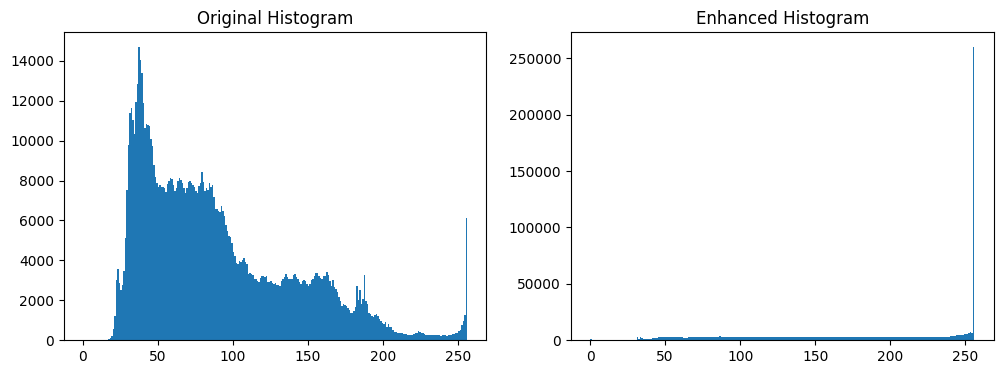

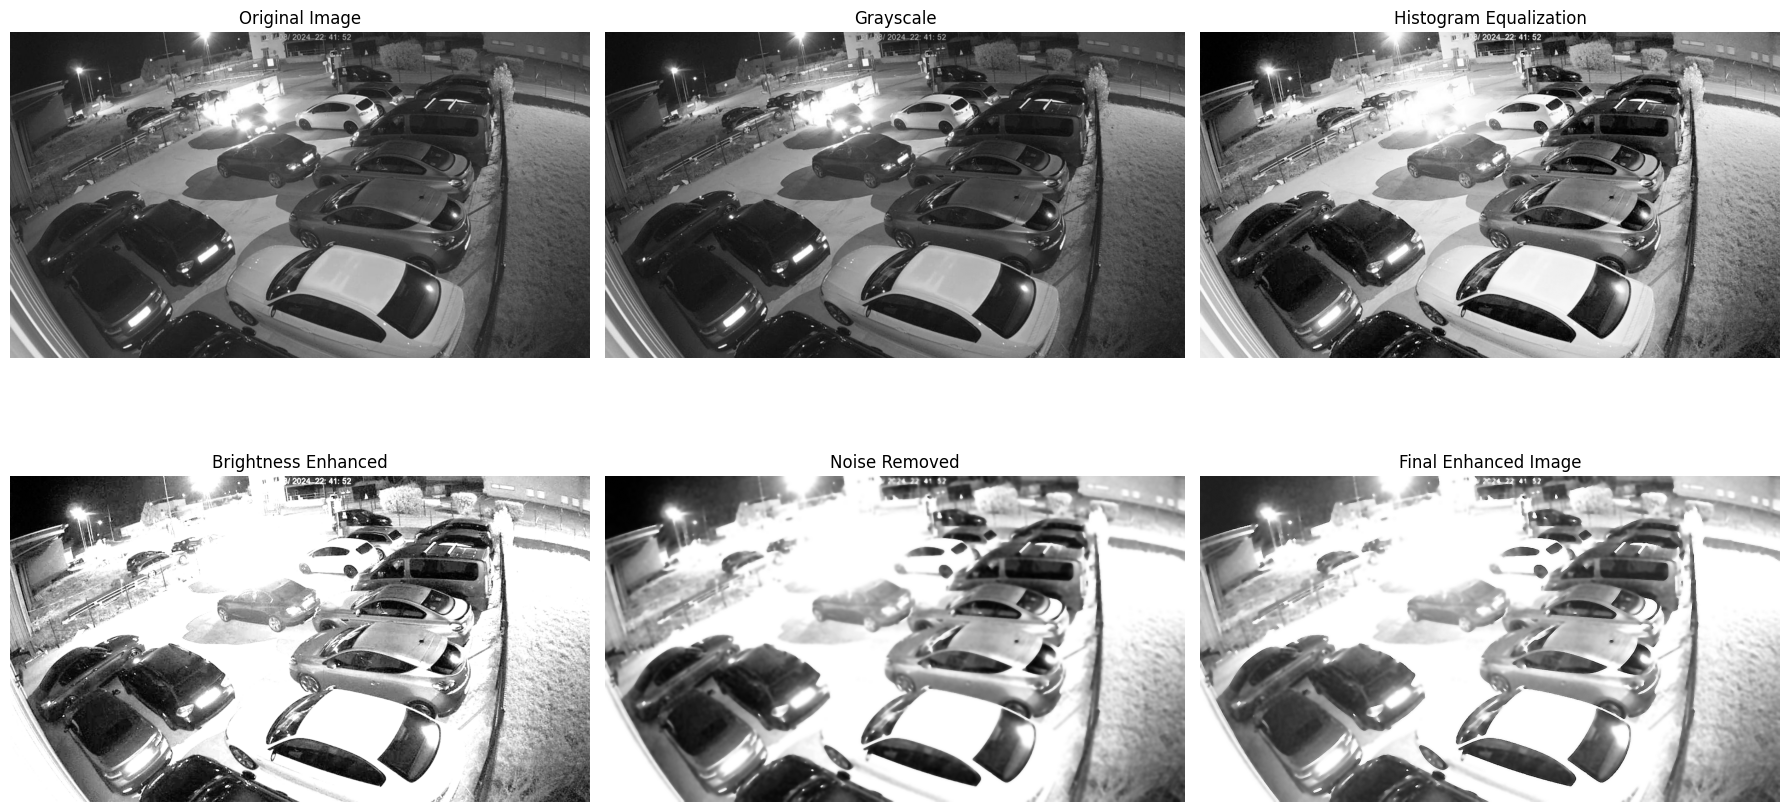


========== IMAGE ENHANCEMENT COMPLETED ==========
✓ Histogram Equalization Applied
✓ Brightness Enhanced
✓ Median Filtering Applied
✓ Bilateral Filtering Applied
✓ Image Sharpened


In [1]:
# ==========================================================
# CCTV NIGHT IMAGE ENHANCEMENT
# Histogram Equalization + Brightness + Noise Removal
# Google Colab
# ==========================================================

# Install OpenCV
!pip -q install opencv-python-headless

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ==========================================================
# Upload Image
# ==========================================================

print("Upload CCTV Night Image")
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

# Read Image
image = cv2.imread(image_path)

# Convert BGR to RGB
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# ==========================================================
# Convert to Grayscale
# ==========================================================

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# ==========================================================
# Histogram Equalization
# ==========================================================

hist_eq = cv2.equalizeHist(gray)

# ==========================================================
# Brightness Enhancement
# ==========================================================

bright = cv2.convertScaleAbs(hist_eq,
                             alpha=1.3,   # Contrast
                             beta=30)     # Brightness

# ==========================================================
# Median Filter (Salt & Pepper Noise Removal)
# ==========================================================

median = cv2.medianBlur(bright, 5)

# ==========================================================
# Bilateral Filter
# Preserves edges while removing noise
# ==========================================================

bilateral = cv2.bilateralFilter(
    median,
    d=9,
    sigmaColor=75,
    sigmaSpace=75
)

# ==========================================================
# Sharpening
# ==========================================================

kernel = np.array([[0,-1,0],
                   [-1,5,-1],
                   [0,-1,0]])

sharp = cv2.filter2D(bilateral,-1,kernel)

# ==========================================================
# Histogram Comparison
# ==========================================================

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(gray.ravel(),256,[0,256])
plt.title("Original Histogram")

plt.subplot(1,2,2)
plt.hist(sharp.ravel(),256,[0,256])
plt.title("Enhanced Histogram")

plt.show()

# ==========================================================
# Display Results
# ==========================================================

plt.figure(figsize=(18,10))

plt.subplot(2,3,1)
plt.imshow(rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(gray,cmap='gray')
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(hist_eq,cmap='gray')
plt.title("Histogram Equalization")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(bright,cmap='gray')
plt.title("Brightness Enhanced")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(bilateral,cmap='gray')
plt.title("Noise Removed")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(sharp,cmap='gray')
plt.title("Final Enhanced Image")
plt.axis("off")

plt.tight_layout()
plt.show()

print("\n========== IMAGE ENHANCEMENT COMPLETED ==========")
print("✓ Histogram Equalization Applied")
print("✓ Brightness Enhanced")
print("✓ Median Filtering Applied")
print("✓ Bilateral Filtering Applied")
print("✓ Image Sharpened")